In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv("Depression Student Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    str    
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    str    
 5   Dietary Habits                         502 non-null    str    
 6   Have you ever had suicidal thoughts ?  502 non-null    str    
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    str    
 10  Depression                             502 non-null    str    
dtypes: float64(2), in

In [4]:
df.describe(include='all')

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,502,502.000000,502.000000,502.000000,502,502,502,502.000000,502.000000,502,502
unique,2,NaN,NaN,NaN,4,3,2,NaN,NaN,2,2
top,Male,NaN,NaN,NaN,7-8 hours,Moderate,Yes,NaN,NaN,No,Yes
freq,267,NaN,NaN,NaN,128,172,260,NaN,NaN,265,252
mean,NaN,26.241036,3.003984,3.075697,NaN,NaN,NaN,6.404382,2.928287,NaN,NaN
std,NaN,4.896501,1.390007,1.373490,NaN,NaN,NaN,3.742434,1.425053,NaN,NaN
min,NaN,18.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,NaN,22.000000,2.000000,2.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN
50%,NaN,26.500000,3.000000,3.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,NaN
75%,NaN,30.000000,4.000000,4.000000,NaN,NaN,NaN,10.000000,4.000000,NaN,NaN


In [5]:
df.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                                       Missing Count  Missing %
Gender                                             0        0.0
Age                                                0        0.0
Academic Pressure                                  0        0.0
Study Satisfaction                                 0        0.0
Sleep Duration                                     0        0.0
Dietary Habits                                     0        0.0
Have you ever had suicidal thoughts ?              0        0.0
Study Hours                                        0        0.0
Financial Stress                                   0        0.0
Family History of Mental Illness                   0        0.0
Depression                                         0        0.0


In [7]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Deletion: drop exact duplicate rows if any exist
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 0
Shape after dropping duplicates: (502, 11)


In [8]:
print("\nCategorical Summary")
print(df.describe(include='object'))


Categorical Summary
       Gender Sleep Duration Dietary Habits  \
count     502            502            502   
unique      2              4              3   
top      Male      7-8 hours       Moderate   
freq      267            128            172   

       Have you ever had suicidal thoughts ? Family History of Mental Illness  \
count                                    502                              502   
unique                                     2                                2   
top                                      Yes                               No   
freq                                     260                              265   

       Depression  
count         502  
unique          2  
top           Yes  
freq          252  


C:\Users\HP\AppData\Local\Temp\ipykernel_3188\616345686.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


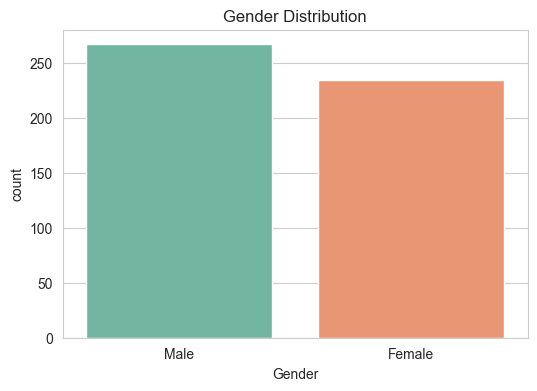

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",          
    palette="Set2",
    legend=False
)

plt.title("Gender Distribution")
plt.show()

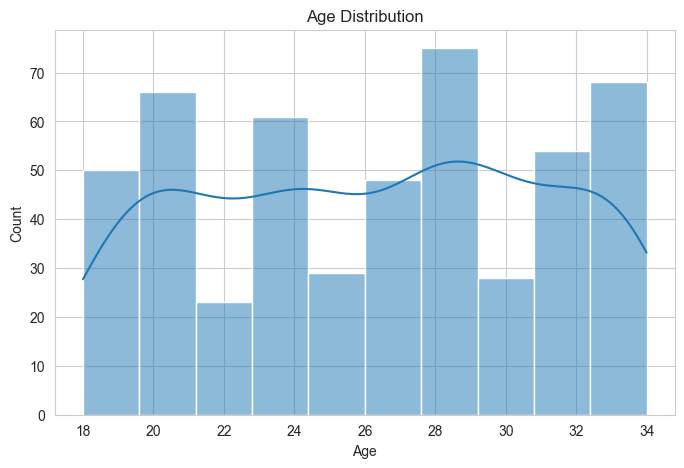

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.show()

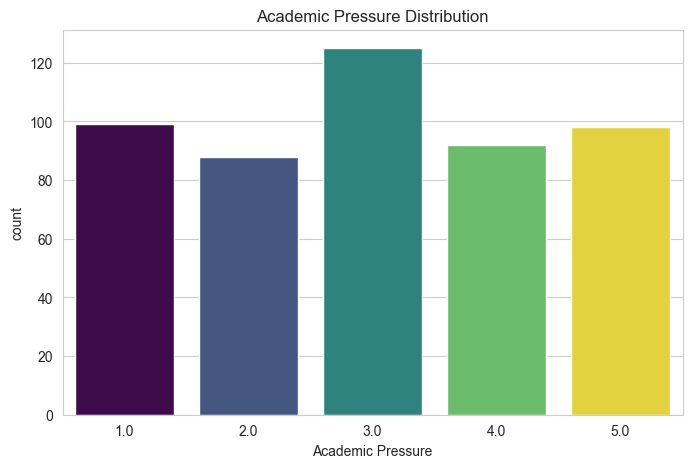

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Academic Pressure",
    hue="Academic Pressure",
    palette="viridis",
    legend=False
)

plt.title("Academic Pressure Distribution")
plt.show()

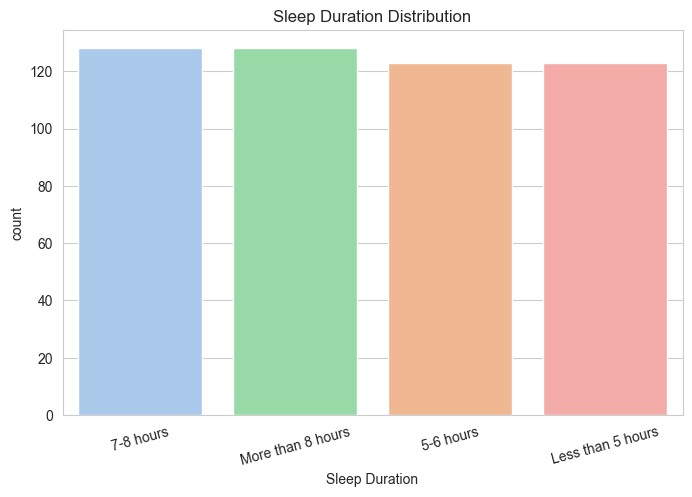

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sleep Duration",
    hue="Sleep Duration",
    order=df["Sleep Duration"].value_counts().index,
    palette="pastel",
    legend=False
)

plt.xticks(rotation=15)
plt.title("Sleep Duration Distribution")
plt.show()

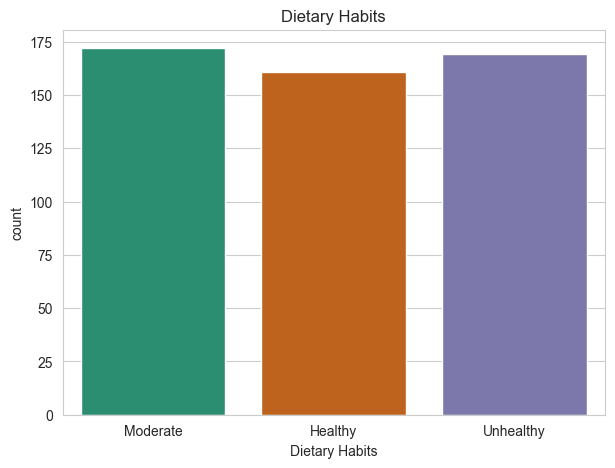

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Dietary Habits",
    hue="Dietary Habits",
    palette="Dark2",
    legend=False
)

plt.title("Dietary Habits")
plt.show()

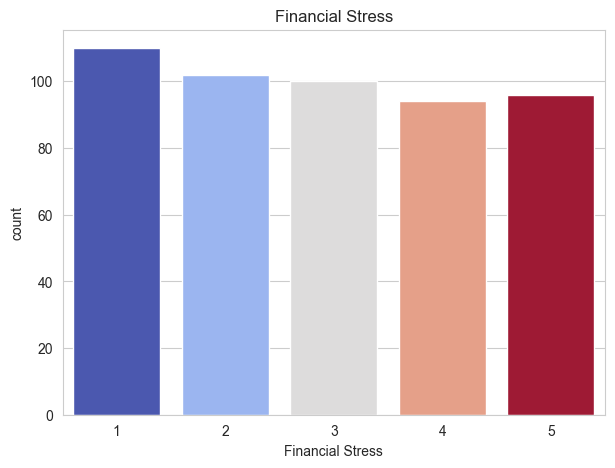

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Financial Stress",
    hue="Financial Stress",
    palette="coolwarm",
    legend=False
)

plt.title("Financial Stress")
plt.show()

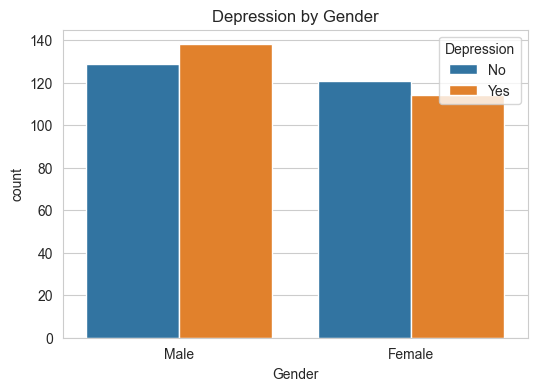

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Gender",
              hue="Depression")

plt.title("Depression by Gender")

plt.show()

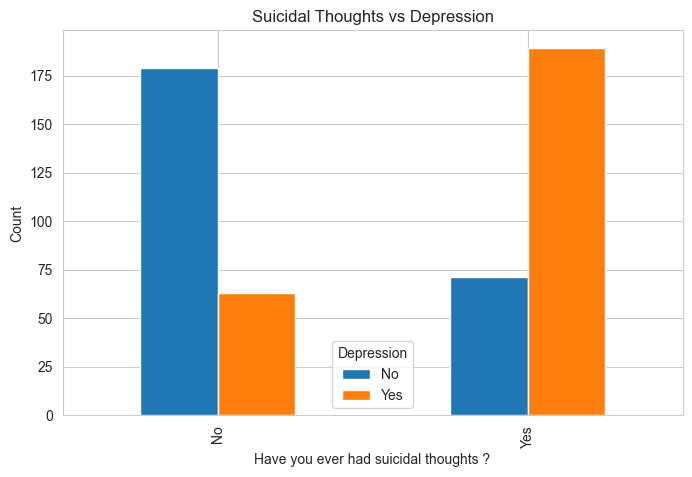

In [28]:
pd.crosstab(df["Have you ever had suicidal thoughts ?"],
            df["Depression"]).plot(kind="bar")

plt.title("Suicidal Thoughts vs Depression")

plt.ylabel("Count")

plt.show()

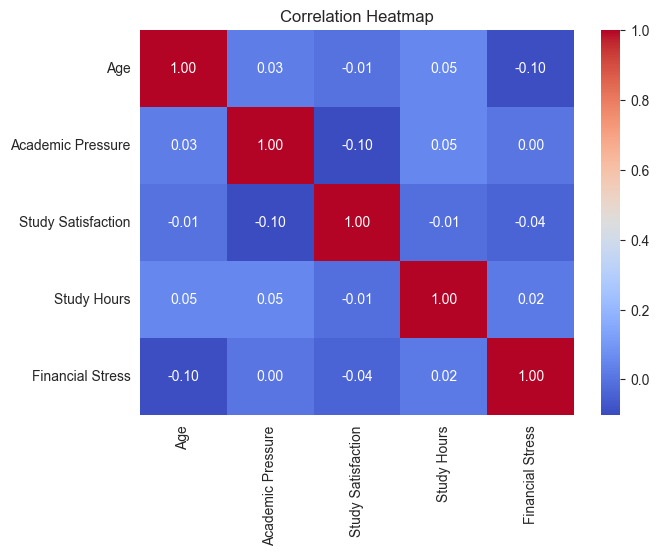

In [31]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(7,5))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

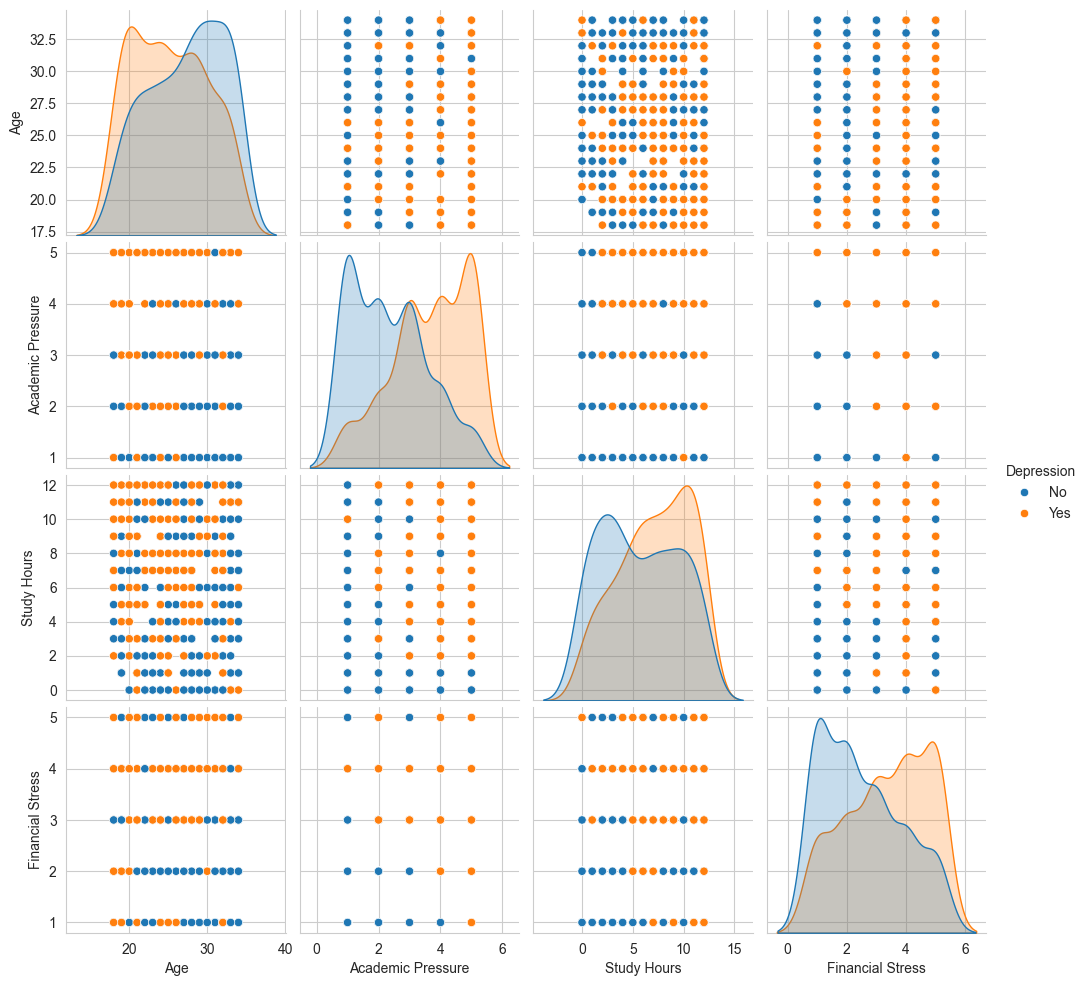

In [32]:
sns.pairplot(
    df,
    vars=[
        "Age",
        "Academic Pressure",
        "Study Hours",
        "Financial Stress"
    ],
    hue="Depression"
)

plt.show()

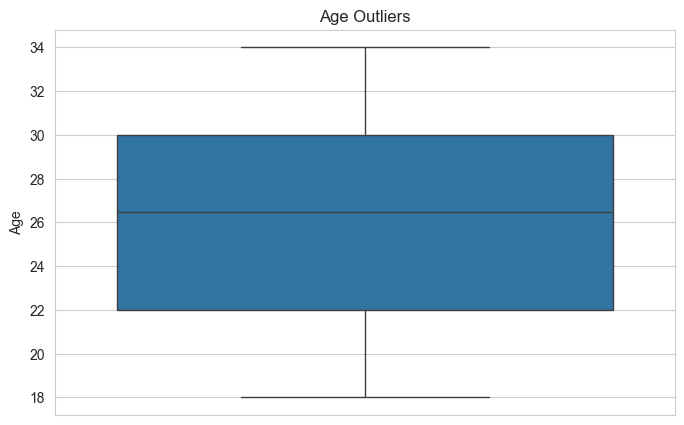

In [33]:
sns.boxplot(y=df["Age"])

plt.title("Age Outliers")

plt.show()

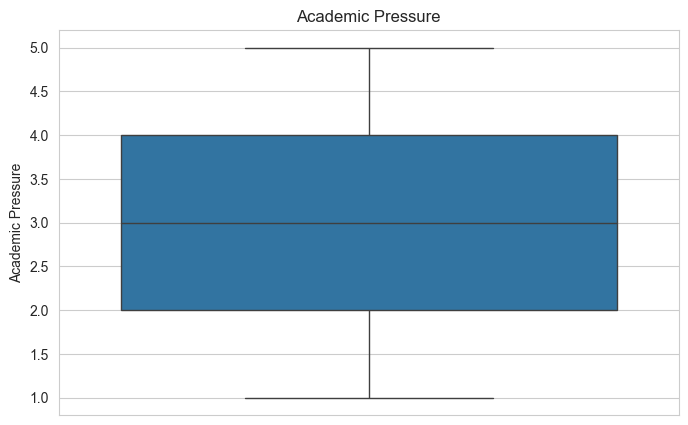

In [34]:
sns.boxplot(y=df["Academic Pressure"])

plt.title("Academic Pressure")

plt.show()

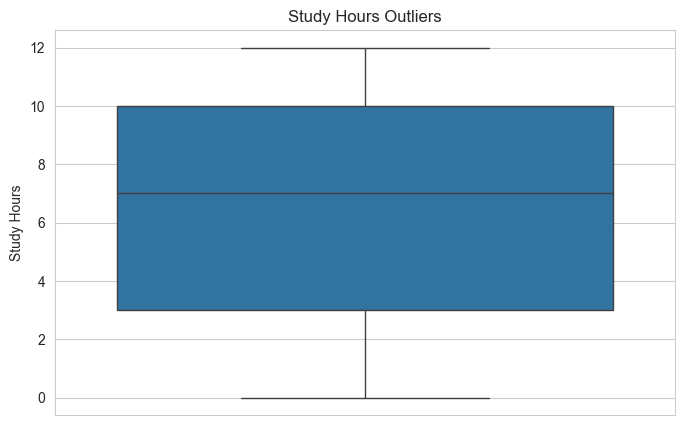

In [35]:
sns.boxplot(y=df["Study Hours"])

plt.title("Study Hours Outliers")

plt.show()

In [36]:
table = pd.crosstab(
    df["Have you ever had suicidal thoughts ?"],
    df["Depression"]
)

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-square:",chi2)
print("p-value:",p)

Chi-square: 107.29249523153612
p-value: 3.840860716984221e-25


In [37]:
if p < 0.05:
    print("Significant association exists.")
else:
    print("No significant association.")

Significant association exists.


In [38]:
yes = df[df["Depression"]=="Yes"]["Study Hours"]

no = df[df["Depression"]=="No"]["Study Hours"]

t,p = ttest_ind(yes,no)

print("T Statistic:",t)
print("P-value:",p)

T Statistic: 4.5748479197192635
P-value: 6.017486311889283e-06


In [39]:
if p < 0.05:
    print("Study Hours differ significantly.")
else:
    print("No significant difference.")

Study Hours differ significantly.


In [40]:
df.groupby("Depression")[
    ["Age",
     "Study Hours",
     "Academic Pressure",
     "Financial Stress",
     "Study Satisfaction"]
].mean()

,Age,Study Hours,Academic Pressure,Financial Stress,Study Satisfaction
Depression,,,,,
No,27.300000,5.652000,2.340000,2.504000,3.480000
Yes,25.190476,7.150794,3.662698,3.349206,2.674603
